<a href="https://colab.research.google.com/github/TaliyaJoseph/A-Hackers-AI-Voice-Assistant/blob/master/RPNNERFMAY.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Google Drive already mounted.
Using device: cuda
CUDA memory available: 15.83 GB
Checking for dataset...
Loading dataset from: /content/drive/MyDrive/DESMAI_TALIYAJOSEPH_2025/Tinynerf/processedrpnmay/nerf_processed_v3.2_20250502131529.pt

Dataset loaded successfully!
Dataset stats:
- Training images: 80
- Validation images: 10
- Resolution: 400x400 (downsampled from 800x800)


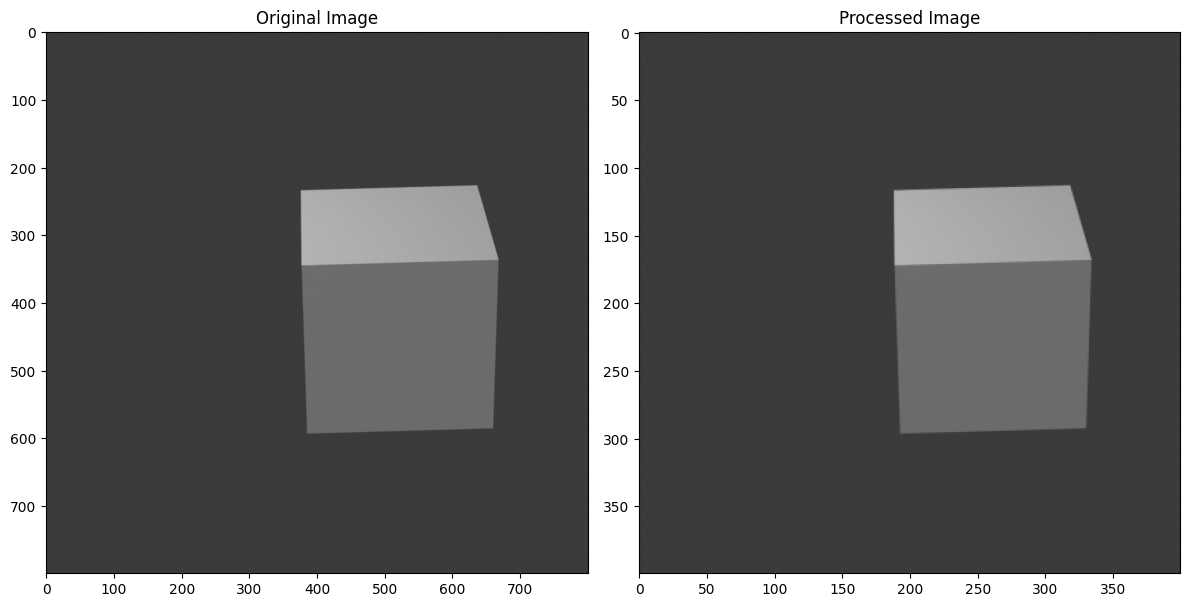

Data preprocessing verified!


In [1]:
# Cell 1: Setup and Dataset Loading
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import time
import os
import json
from pathlib import Path
from datetime import datetime
from tqdm import tqdm
from PIL import Image
from torch.serialization import safe_globals
from numpy._core.multiarray import scalar  # Required for safe loading

# Check if drive is already mounted
drive_mounted = os.path.exists('/content/drive') and os.path.isdir('/content/drive/MyDrive')
if not drive_mounted:
    from google.colab import drive
    print("Mounting Google Drive...")
    drive.mount('/content/drive')
else:
    print("Google Drive already mounted.")

# Path configuration
PROCESSED_DIR = "/content/drive/MyDrive/DESMAI_TALIYAJOSEPH_2025/Tinynerf/processedrpnmay"
SAVE_DIR = "/content/drive/MyDrive/DESMAI_TALIYAJOSEPH_2025/Tinynerf/results"
MODELS_DIR = "/content/drive/MyDrive/DESMAI_TALIYAJOSEPH_2025/Tinynerf/models"
DATA_PATH = "/content/drive/MyDrive/DESMAI_TALIYAJOSEPH_2025/Tinynerf/cube5"  # Original data path

# Create directories if they don't exist
for dir_path in [PROCESSED_DIR, SAVE_DIR, MODELS_DIR]:
    Path(dir_path).mkdir(parents=True, exist_ok=True)

# Check device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Clean up CUDA memory if available
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print(f"CUDA memory available: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

# Allow list for safe loading
torch.serialization.add_safe_globals([np.dtype, scalar])

# Improved dataset loading function
def secure_dataset_load(processed_dir):
    """Securely load a processed NeRF dataset with validation"""
    try:
        dataset_files = sorted(
            Path(processed_dir).glob("nerf_processed_v3.2_*.pt"),
            key=lambda f: f.stat().st_ctime,
            reverse=True
        )

        if not dataset_files:
            print(f"No dataset files found in {processed_dir}")
            print(f"Looking for files matching: nerf_processed_v3.2_*.pt")

            # List all files in the directory to help debug
            all_files = list(Path(processed_dir).glob("*"))
            if all_files:
                print(f"Found these files instead: {[f.name for f in all_files]}")
            else:
                print(f"Directory is empty or doesn't exist")

            return None

        print(f"Loading dataset from: {dataset_files[0]}")

        # Use safe loading with proper error handling
        with safe_globals([scalar, np.dtype]):
            try:
                # First try with weights_only=False
                data = torch.load(
                    dataset_files[0],
                    map_location='cpu',
                    weights_only=False
                )
            except Exception as e:
                print(f"Error with weights_only=False: {e}")
                print("Trying with pickle_module...")
                # Try alternative loading method
                data = torch.load(
                    dataset_files[0],
                    map_location='cpu',
                    pickle_module=torch.serialization._get_default_unpickler()
                )

        required_structure = {
            'metadata': {'version': '3.2', 'resolution': str, 'security': dict},
            'dataset': {'train': ['images', 'poses', 'H', 'W', 'focal'], 'val': ['images', 'poses', 'H', 'W', 'focal']}
        }

        errors = []
        for key in required_structure:
            if key not in data:
                errors.append(f"Missing root key: {key}")
        if 'metadata' in data:
            if data['metadata'].get('version') != '3.2':
                errors.append("Version mismatch detected")
            if 'security' not in data['metadata']:
                errors.append("Missing security metadata")
        if 'dataset' in data:
            for split in ['train', 'val']:
                if split not in data['dataset']:
                    errors.append(f"Missing {split} split")
                else:
                    for field in required_structure['dataset'][split]:
                        if field not in data['dataset'][split]:
                            errors.append(f"Missing {field} in {split} split")

        if errors:
            print(f"Dataset validation failed with errors:")
            for e in errors:
                print(f" - {e}")
            return None

        return data['dataset']

    except Exception as e:
        print(f"Error loading dataset: {e}")
        return None

# Function to process raw data if needed
def load_split_and_process(data_root, splits={'train':0.8, 'val':0.1, 'test':0.1}, seed=42):
    """Academic NeRF processor with rigorous validation"""
    data_root = Path(data_root)

    # =====================
    # 1. Academic Validation
    # =====================
    if not (data_root/'transforms.json').exists():
        raise FileNotFoundError(f"Missing transforms.json in {data_root}")

    # =====================
    # 2. Metadata Processing
    # =====================
    with open(data_root/'transforms.json') as f:
        meta = json.load(f)

    # =====================
    # 3. Camera Calibration
    # =====================
    sample_img_files = list(data_root.glob('rgb_*.png'))
    if not sample_img_files:
        raise FileNotFoundError(f"No rgb_*.png files found in {data_root}")

    sample_img = sample_img_files[0]
    img = Image.open(sample_img)
    W, H = img.size
    focal = (W/2) / np.tan(meta['camera_angle_x']/2)

    # =====================
    # 4. Academic Splitting
    # =====================
    rng = np.random.default_rng(seed)
    indices = rng.permutation(len(meta['frames']))

    dataset = {}
    split_bounds = {
        'train': (0, int(0.8*len(indices))),
        'val': (int(0.8*len(indices)), int(0.9*len(indices))),
        'test': (int(0.9*len(indices)), None)
    }

    # =====================
    # 5. Secure Data Loading
    # =====================
    for split, (start, end) in split_bounds.items():
        split_indices = indices[start:end] if end else indices[start:]

        images, poses = [], []
        missing_files = {'depth': 0, 'normal': 0}

        for idx in split_indices:
            frame = meta['frames'][idx]
            try:
                # 5.1 Frame ID Extraction
                frame_id = Path(frame['file_path']).name.split('_')[-1].zfill(4)

                # 5.2 Core RGB Validation
                rgb_path = data_root / f"rgb_{frame_id}.png"
                if not rgb_path.exists():
                    raise FileNotFoundError(f"Missing RGB: {rgb_path.name}")

                # 5.3 Image Processing
                img = np.array(Image.open(rgb_path)) / 255.0
                if img.shape[-1] == 4:  # Alpha handling
                    img = img[..., :3] * img[..., 3:] + (1 - img[..., 3:])
                elif img.shape[-1] != 3:
                    raise ValueError("Invalid image dimensions")

                # 5.4 Pose Validation
                pose = np.array(frame['transform_matrix'], dtype=np.float32)
                if pose.shape != (4, 4):
                    raise ValueError("Pose matrix must be 4x4")
                pose[:3, 1:3] *= -1  # NeRF coord conversion

                # 5.5 Auxiliary Checks
                if not (data_root / f"Depth{frame_id}.exr").exists():
                    missing_files['depth'] += 1
                if not (data_root / f"Normal{frame_id}.exr").exists():
                    missing_files['normal'] += 1

                images.append(torch.from_numpy(img[..., :3]).float())
                poses.append(torch.from_numpy(pose).float())

            except Exception as e:
                print(f"Skipped frame {idx}: {str(e)}")
                continue

        # 5.6 Split Validation
        if len(images) < 5:
            raise RuntimeError(f"Insufficient data in {split} split (min 5 frames required)")

        dataset[split] = {
            'images': torch.stack(images),
            'poses': torch.stack(poses),
            'H': H,
            'W': W,
            'focal': focal
        }

        # 5.7 Security Warnings
        for ftype, count in missing_files.items():
            if count > 0:
                print(f"Security Note: Missing {count} {ftype} maps in {split}")

    # =====================
    # 6. Academic Visualization
    # =====================
    def generate_plots():
        plt.figure(figsize=(20, 12))

        # 6.1 Sample Frame
        plt.subplot(2,3,1)
        plt.imshow(dataset['train']['images'][0].numpy())
        plt.title("Training Sample")

        # 6.2 Camera Positions
        for i, split in enumerate(['train','val']):
            plt.subplot(2,3,2+i)
            poses = dataset[split]['poses'][:,:3,3].numpy()
            plt.scatter(poses[:,0], poses[:,1], s=15, label=split)
            plt.gca().set_aspect('equal')
            plt.legend()

        # 6.3 3D View
        ax = plt.subplot(1,3,3, projection='3d')
        colors = {'train':'blue', 'val':'orange'}
        for split in ['train','val']:
            poses = dataset[split]['poses'][:,:3,3].numpy()
            ax.scatter(poses[:,0], poses[:,1], poses[:,2], c=colors[split], label=f"{split} ({len(poses)})")
        ax.legend()

        plt.tight_layout()
        plt.show()

    generate_plots()

    return dataset

def save_academic_dataset(dataset, save_dir):
    """Secure dataset serialization with academic metadata"""
    metadata = {
        'version': '3.2',
        'creation_date': datetime.utcnow().isoformat(),
        'splits': {k: len(v['images']) for k,v in dataset.items()},
        'resolution': f"{dataset['train']['H']}x{dataset['train']['W']}",
        'coordinate_system': 'NeRF (Blender Standard)',
        'security': {
            'checksum': hash(tuple(dataset['train']['images'].numpy().ravel())),
            'validation': 'Passed'
        }
    }

    save_path = Path(save_dir) / f"nerf_processed_v3.2_{datetime.now().strftime('%Y%m%d%H%M%S')}.pt"
    save_path.parent.mkdir(parents=True, exist_ok=True)

    torch.save({
        'metadata': metadata,
        'dataset': dataset  # Critical key for loading
    }, save_path)

    print(f"Academic Dataset Saved:\n{save_path}\nChecksum: {metadata['security']['checksum']}")
    return save_path

# Check for the dataset and create it if necessary
print("Checking for dataset...")
dataset = secure_dataset_load(PROCESSED_DIR)

if dataset is None:
    print("\nNo valid dataset found. Attempting to create dataset from raw data...")

    # Check if raw data exists
    if Path(DATA_PATH).exists() and (Path(DATA_PATH)/'transforms.json').exists():
        print(f"Found raw data at {DATA_PATH}. Processing data...")
        try:
            # Process the raw data
            dataset = load_split_and_process(DATA_PATH)
            # Save the processed dataset
            save_path = save_academic_dataset(dataset, PROCESSED_DIR)
            print(f"Dataset created and saved to {save_path}")
        except Exception as e:
            print(f"Error processing raw data: {e}")
            dataset = None
    else:
        print(f"Raw data not found at {DATA_PATH}.")
        print("Please ensure your data path is correct and contains the necessary files.")
        dataset = None

if dataset is not None:
    print("\nDataset loaded successfully!")

    # Get dataset properties
    H, W = dataset['train']['H'] // 2, dataset['train']['W'] // 2  # Downsample for faster training
    focal = dataset['train']['focal'] / 2  # Adjust focal length for downsizing

    # Display dataset info
    print(f"Dataset stats:")
    print(f"- Training images: {len(dataset['train']['images'])}")
    print(f"- Validation images: {len(dataset['val']['images'])}")
    print(f"- Resolution: {H}x{W} (downsampled from {dataset['train']['H']}x{dataset['train']['W']})")

    # Preprocess a sample to verify everything works
    sample_img = dataset['train']['images'][0]
    sample_processed = F.interpolate(sample_img.permute(2,0,1).unsqueeze(0),
                                   (H, W), mode='bilinear').squeeze(0).permute(1,2,0)

    # Display sample image
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(sample_img.numpy())
    plt.title("Original Image")

    plt.subplot(1, 2, 2)
    plt.imshow(sample_processed.numpy())
    plt.title("Processed Image")

    plt.tight_layout()
    plt.show()

    print("Data preprocessing verified!")
else:
    print("\nCould not load or create dataset. Please verify your data paths and file structure.")
    print("Here are the directories we're using:")
    print(f"- Processed data directory: {PROCESSED_DIR}")
    print(f"- Raw data directory: {DATA_PATH}")
    print(f"- Models directory: {MODELS_DIR}")
    print(f"- Results directory: {SAVE_DIR}")

    # List the contents of the directories
    print("\nChecking directory contents:")
    for dir_path in [PROCESSED_DIR, DATA_PATH]:
        if Path(dir_path).exists():
            files = list(Path(dir_path).glob("*"))
            print(f"\nFiles in {dir_path}:")
            for f in files:
                print(f"  - {f.name}")
        else:
            print(f"\n{dir_path} does not exist.")

In [7]:
# Cell 2: Model Implementation (with dynamic input-dims and positive initial density)

import torch
import torch.nn as nn
import torch.nn.functional as F

# ─── Positional Encoder ────────────────────────────────────────────────────────
class PositionalEncoder(nn.Module):
    def __init__(self, L_embed=10):
        super().__init__()
        self.L_embed = L_embed
        # frequency bands: [1, 2, 4, …, 2^(L_embed-1)]
        self.register_buffer('freq_bands', 2.**torch.arange(L_embed))

    def forward(self, x):
        """
        x: Tensor of shape [N,3]
        returns: Tensor of shape [N, C] where C = 3 * (1 + 2*L_embed)
        """
        encoded = [x]
        for freq in self.freq_bands:
            encoded.append(torch.sin(freq * x))
            encoded.append(torch.cos(freq * x))
        return torch.cat(encoded, dim=-1)

# ─── TinyNeRF ───────────────────────────────────────────────────────────────────
class TinyNeRF(nn.Module):
    def __init__(self, L_embed=10, D=8, W=256):
        super().__init__()
        # 1) build positional encoder
        self.encoder = PositionalEncoder(L_embed)

        # 2) determine input dimension automatically
        with torch.no_grad():
            dummy = torch.zeros(1, 3)
            input_dim = self.encoder(dummy).shape[-1]

        # 3) construct MLP layers (skip-connections every 4 layers)
        self.layers = nn.ModuleList()
        self.layers.append(nn.Linear(input_dim, W))
        for i in range(1, D):
            if i % 4 == 0:
                self.layers.append(nn.Linear(W + input_dim, W))
            else:
                self.layers.append(nn.Linear(W, W))

        # 4) output heads
        self.rgb_output     = nn.Linear(W, 3)
        self.density_output = nn.Linear(W, 1)

        # 5) proper weight initialization
        self._init_weights()

    def _init_weights(self):
        # initialize MLP layers
        for i, layer in enumerate(self.layers):
            if i == 0 or (i % 4 == 0):
                nn.init.xavier_uniform_(layer.weight)
            else:
                nn.init.kaiming_normal_(layer.weight, nonlinearity='relu')
            nn.init.zeros_(layer.bias)
        # initialize RGB head to mid-gray
        nn.init.constant_(self.rgb_output.weight, 0.0)
        nn.init.constant_(self.rgb_output.bias,   0.0)
        # initialize density head with positive bias → initial σ>0
        nn.init.constant_(self.density_output.weight, 0.0)
        nn.init.constant_(self.density_output.bias,   1.0)

    def forward(self, x):
        """
        x: Tensor [N,3] world-space 3D points
        returns: Tensor [N,4] concatenated [r,g,b,density]
        """
        enc = self.encoder(x)  # [N, input_dim]
        h   = enc
        for i, layer in enumerate(self.layers):
            if i % 4 == 0 and i > 0:
                h = torch.cat([h, enc], dim=-1)
            h = F.relu(layer(h))
        rgb     = torch.sigmoid(self.rgb_output(h))
        density = self.density_output(h)
        return torch.cat([rgb, density], dim=-1)

# ─── Instantiate on your device ────────────────────────────────────────────────
model = TinyNeRF(L_embed=10, D=8, W=256).to(device)
print("✅ TinyNeRF model instantiated with positive density bias and dynamic input dims.")


✅ TinyNeRF model instantiated with positive density bias and dynamic input dims.


Starting TinyNeRF training for 5000 iterations...


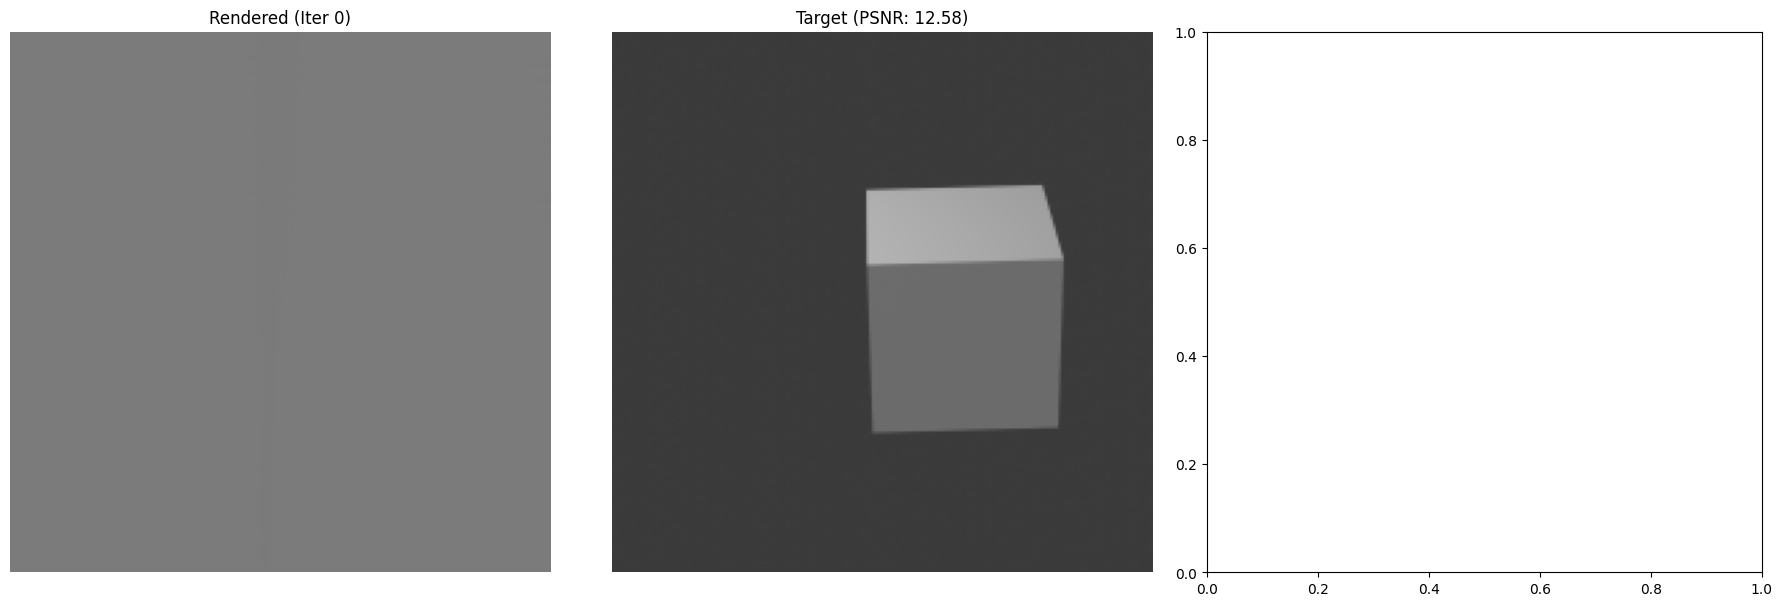

[Iter 0/5000] Loss: 0.060305, PSNR: 12.58, Time: 1.78s


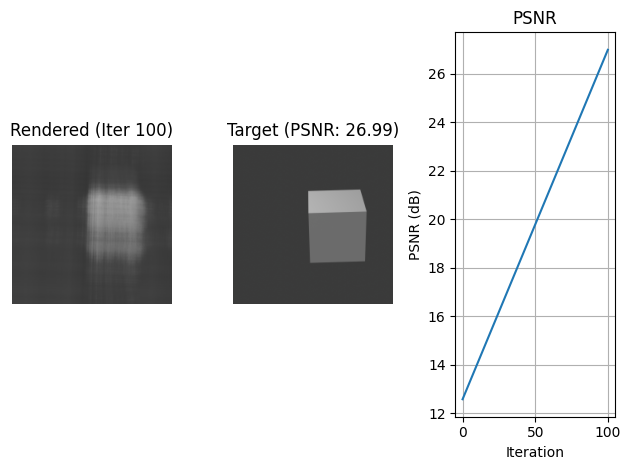

[Iter 100/5000] Loss: 0.001745, PSNR: 26.99, Time: 8.75s


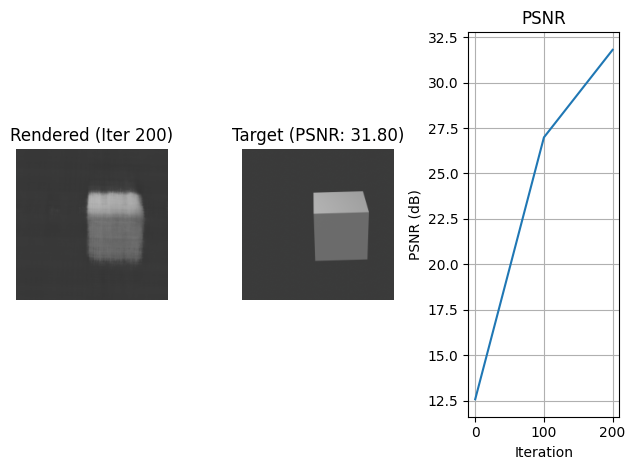

[Iter 200/5000] Loss: 0.000604, PSNR: 31.80, Time: 8.94s


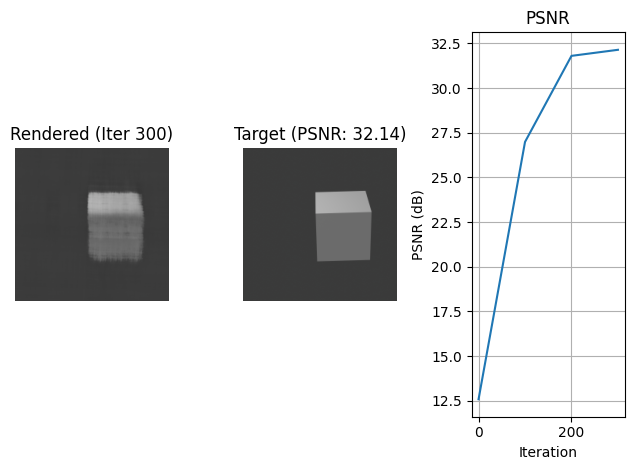

[Iter 300/5000] Loss: 0.000380, PSNR: 32.14, Time: 8.89s


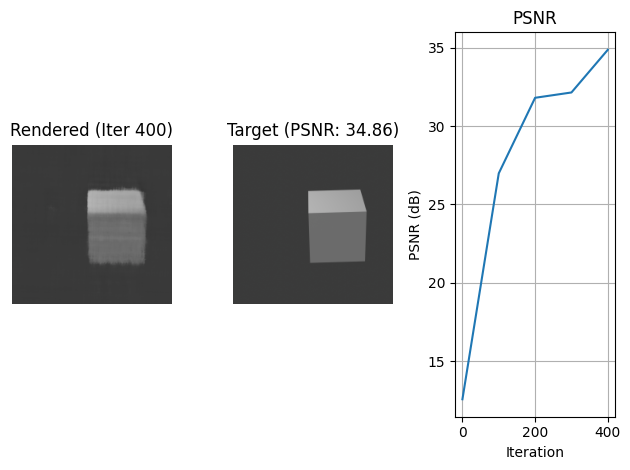

[Iter 400/5000] Loss: 0.000311, PSNR: 34.86, Time: 8.91s


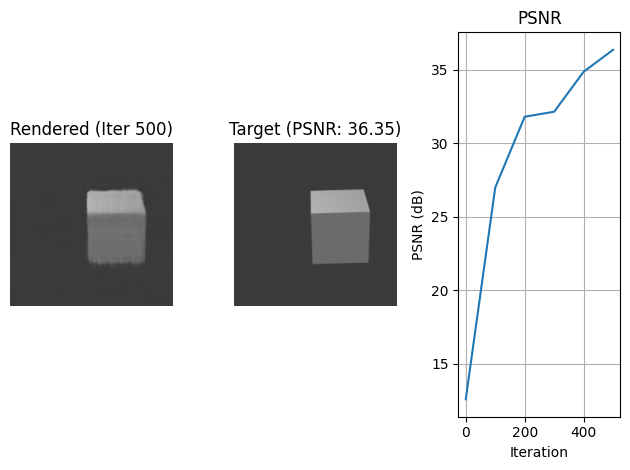

[Iter 500/5000] Loss: 0.000170, PSNR: 36.35, Time: 10.08s


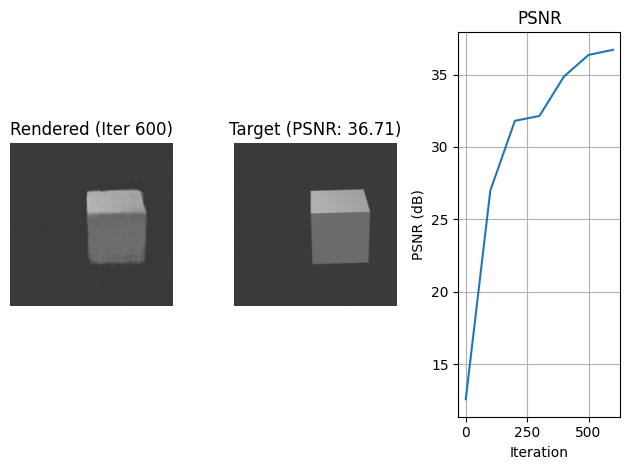

[Iter 600/5000] Loss: 0.000292, PSNR: 36.71, Time: 8.77s


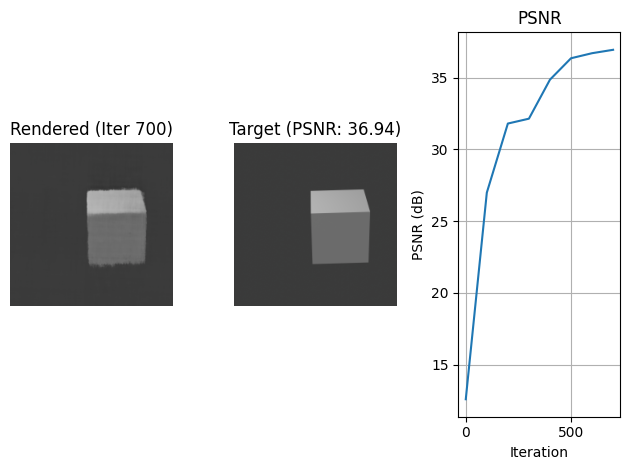

[Iter 700/5000] Loss: 0.000102, PSNR: 36.94, Time: 8.79s


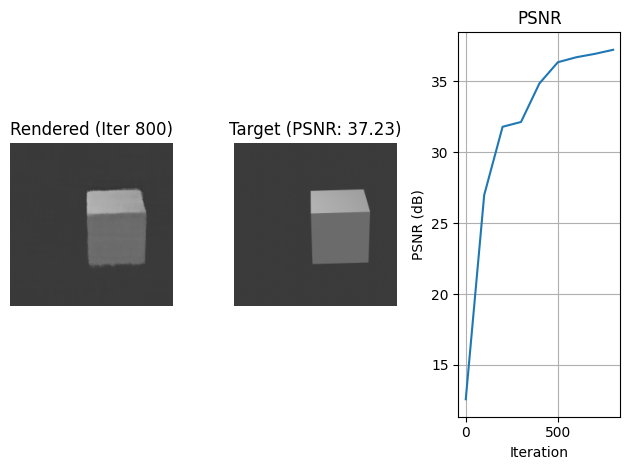

[Iter 800/5000] Loss: 0.000089, PSNR: 37.23, Time: 8.88s


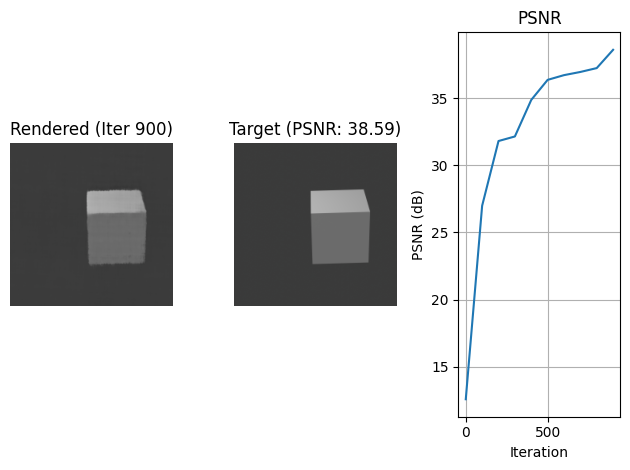

[Iter 900/5000] Loss: 0.000123, PSNR: 38.59, Time: 8.67s


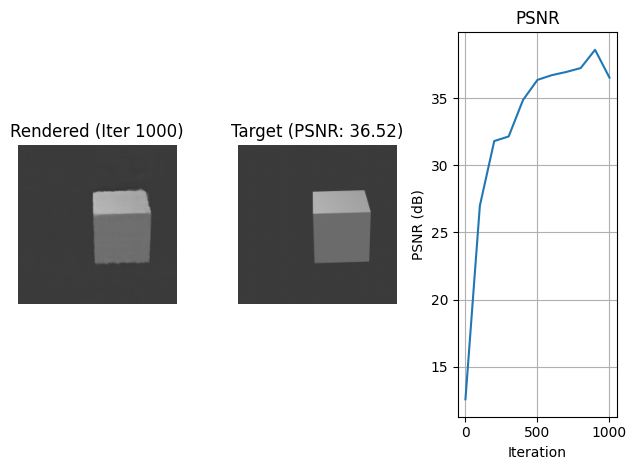

[Iter 1000/5000] Loss: 0.000153, PSNR: 36.52, Time: 8.77s


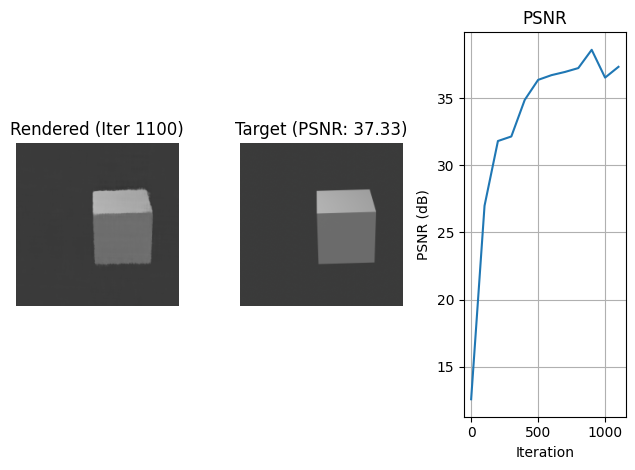

[Iter 1100/5000] Loss: 0.000098, PSNR: 37.33, Time: 8.85s


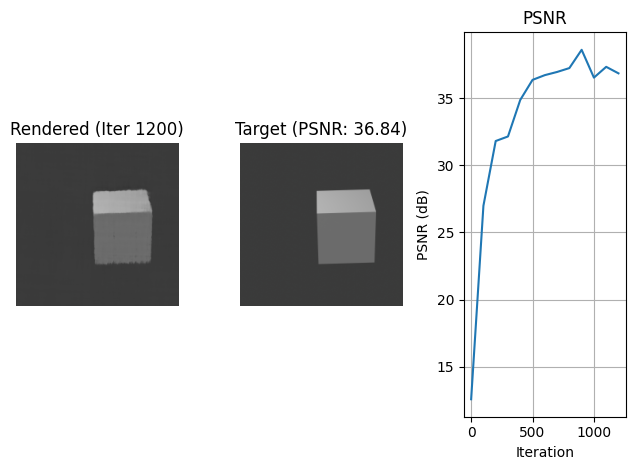

[Iter 1200/5000] Loss: 0.000081, PSNR: 36.84, Time: 8.71s


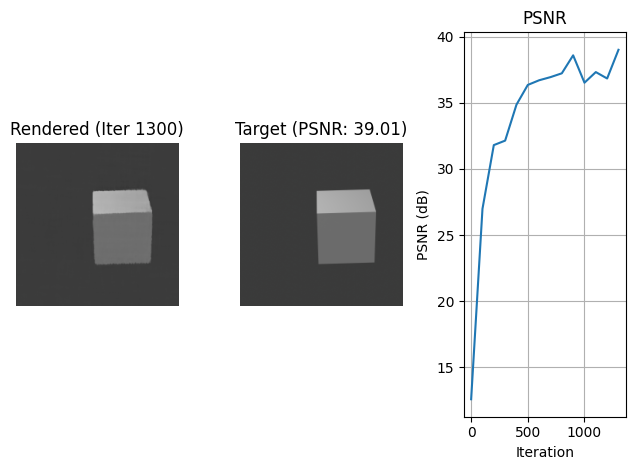

[Iter 1300/5000] Loss: 0.000133, PSNR: 39.01, Time: 8.78s


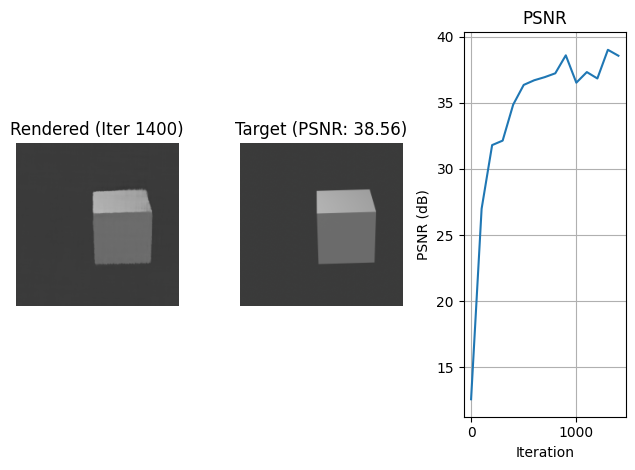

[Iter 1400/5000] Loss: 0.000038, PSNR: 38.56, Time: 8.86s


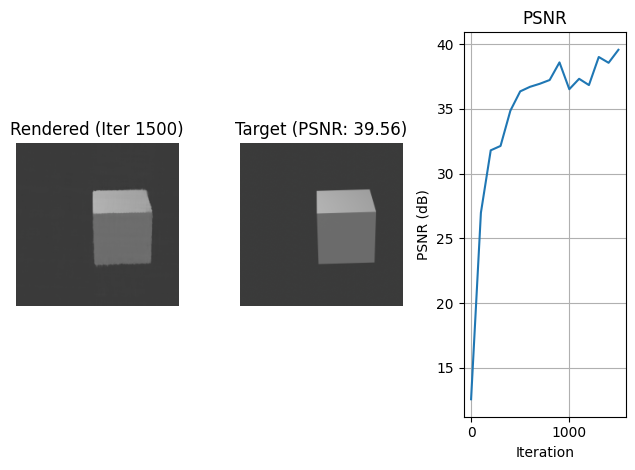

[Iter 1500/5000] Loss: 0.000060, PSNR: 39.56, Time: 8.69s


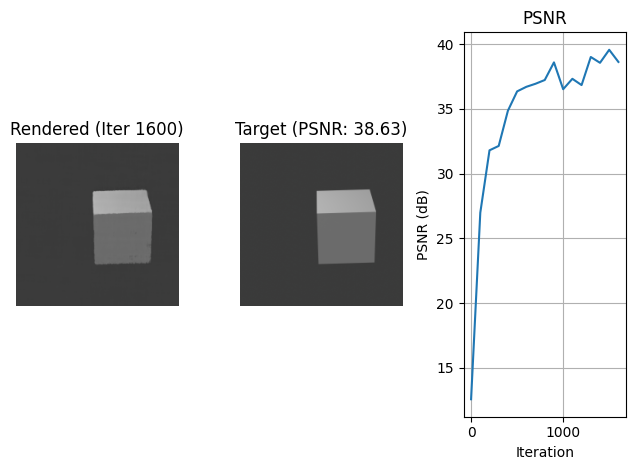

[Iter 1600/5000] Loss: 0.000078, PSNR: 38.63, Time: 8.75s


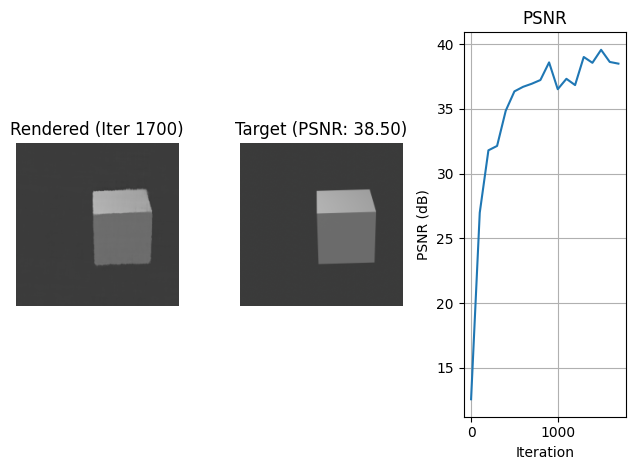

[Iter 1700/5000] Loss: 0.000025, PSNR: 38.50, Time: 8.85s


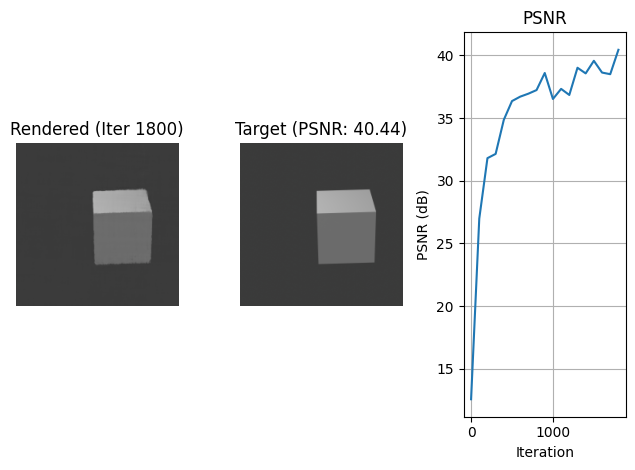

[Iter 1800/5000] Loss: 0.000027, PSNR: 40.44, Time: 8.82s


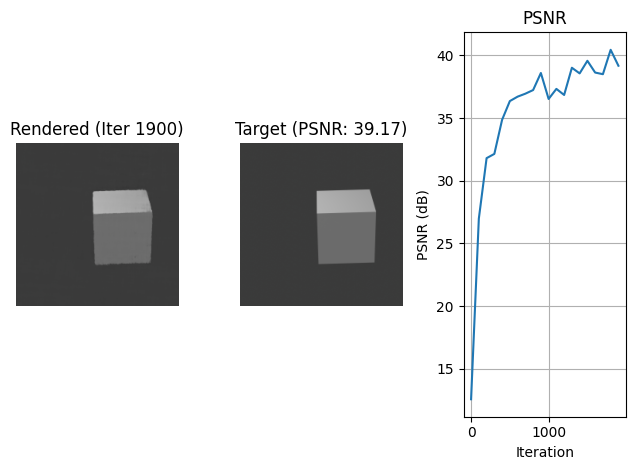

[Iter 1900/5000] Loss: 0.000045, PSNR: 39.17, Time: 8.73s


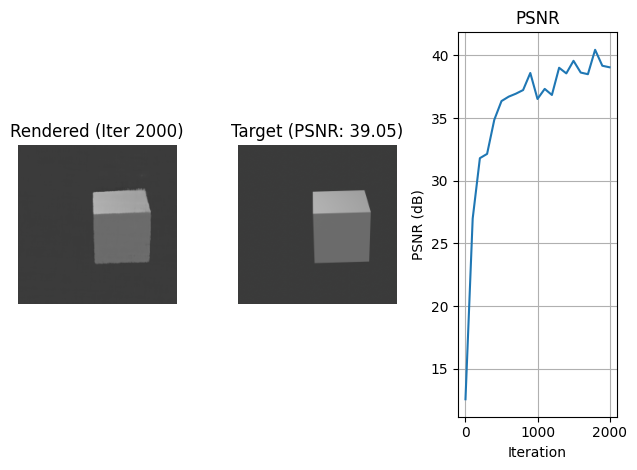

[Iter 2000/5000] Loss: 0.000067, PSNR: 39.05, Time: 8.79s


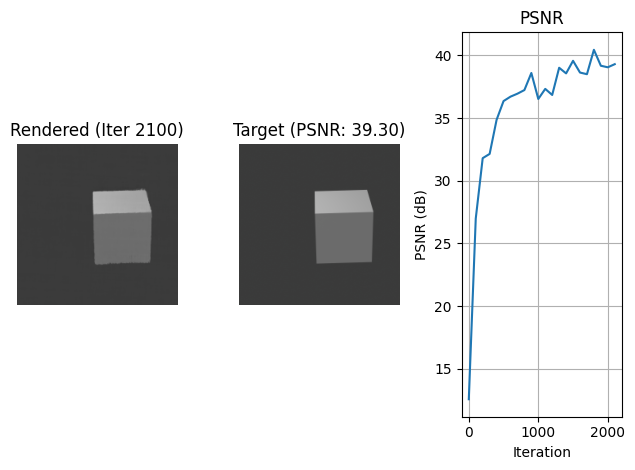

[Iter 2100/5000] Loss: 0.000035, PSNR: 39.30, Time: 8.61s


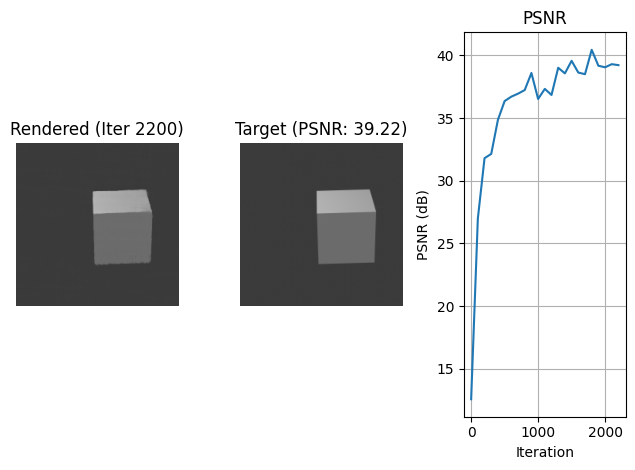

[Iter 2200/5000] Loss: 0.000041, PSNR: 39.22, Time: 8.72s


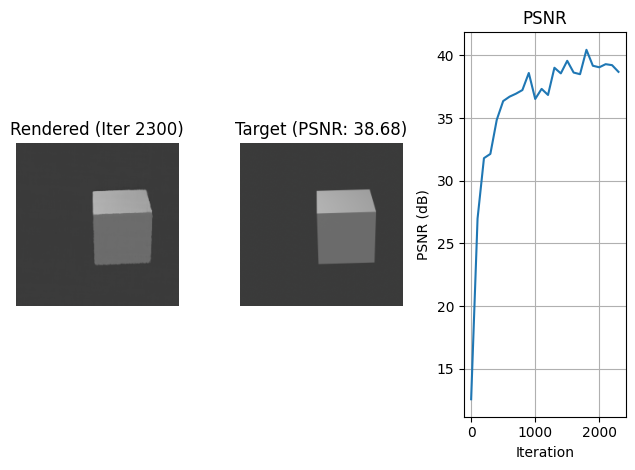

[Iter 2300/5000] Loss: 0.000028, PSNR: 38.68, Time: 8.87s


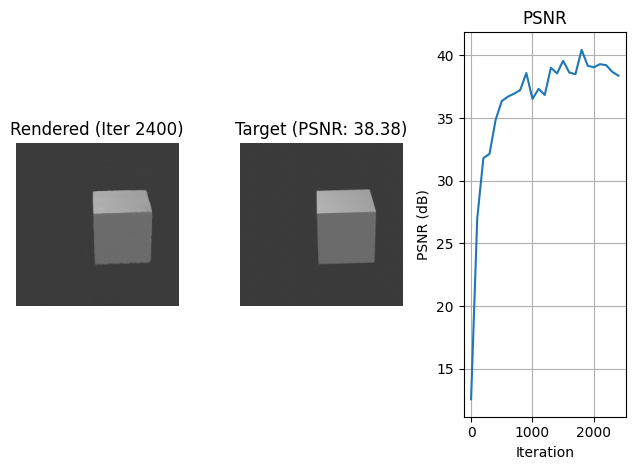

[Iter 2400/5000] Loss: 0.000036, PSNR: 38.38, Time: 8.62s


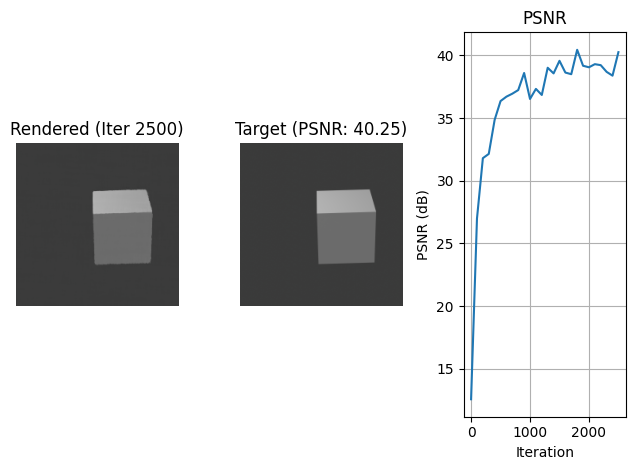

[Iter 2500/5000] Loss: 0.000018, PSNR: 40.25, Time: 8.71s


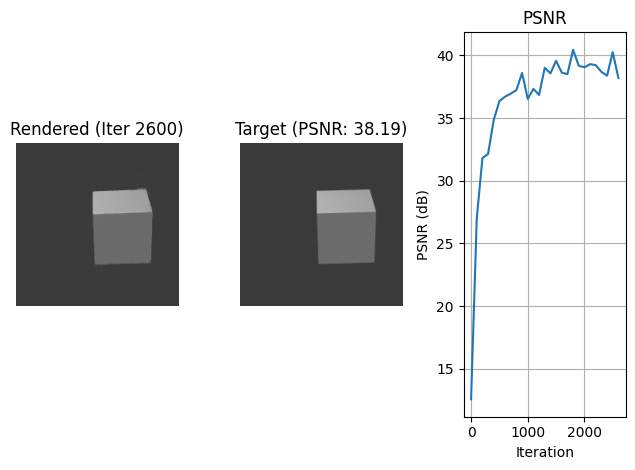

[Iter 2600/5000] Loss: 0.000014, PSNR: 38.19, Time: 8.84s


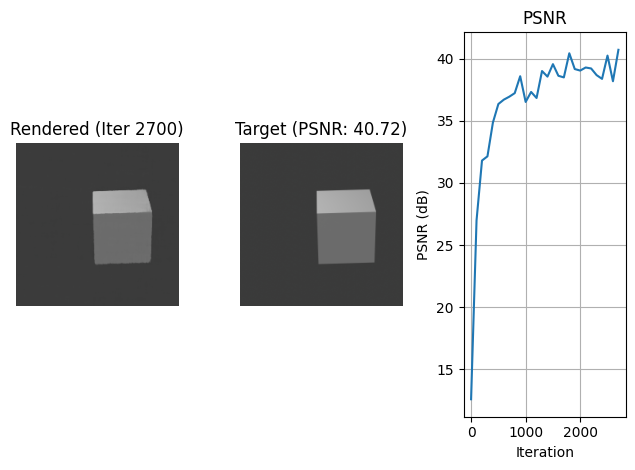

[Iter 2700/5000] Loss: 0.000009, PSNR: 40.72, Time: 8.65s


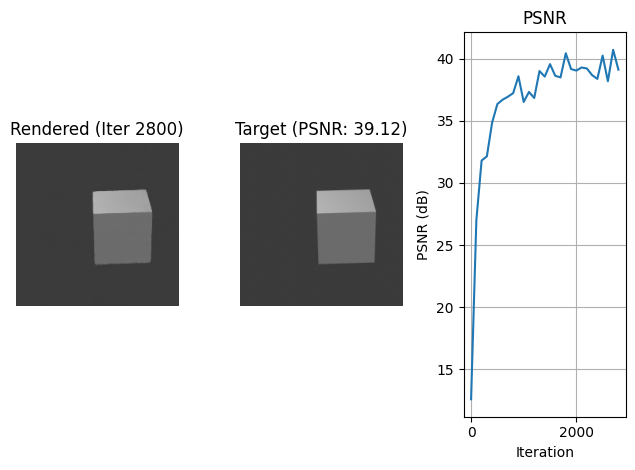

[Iter 2800/5000] Loss: 0.000069, PSNR: 39.12, Time: 8.71s


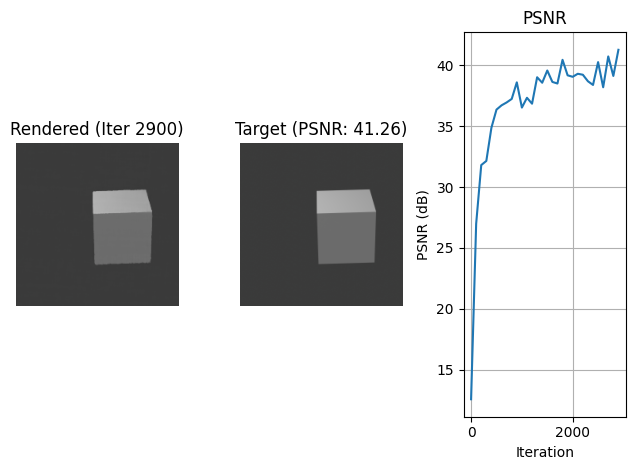

[Iter 2900/5000] Loss: 0.000009, PSNR: 41.26, Time: 8.86s


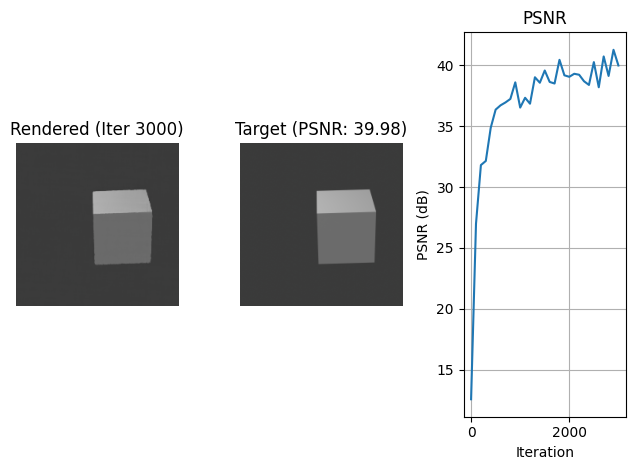

[Iter 3000/5000] Loss: 0.000015, PSNR: 39.98, Time: 8.64s


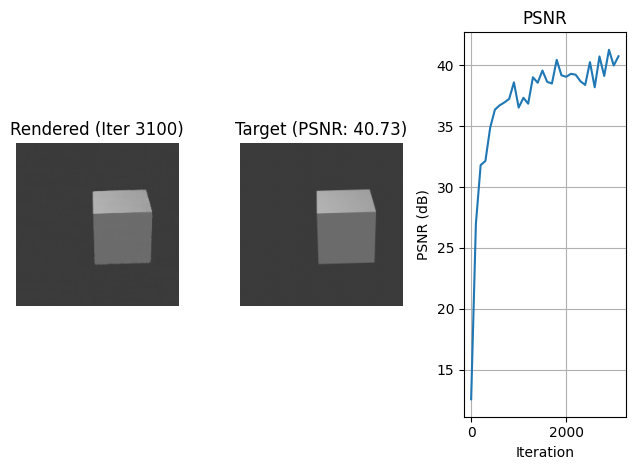

[Iter 3100/5000] Loss: 0.000007, PSNR: 40.73, Time: 8.89s


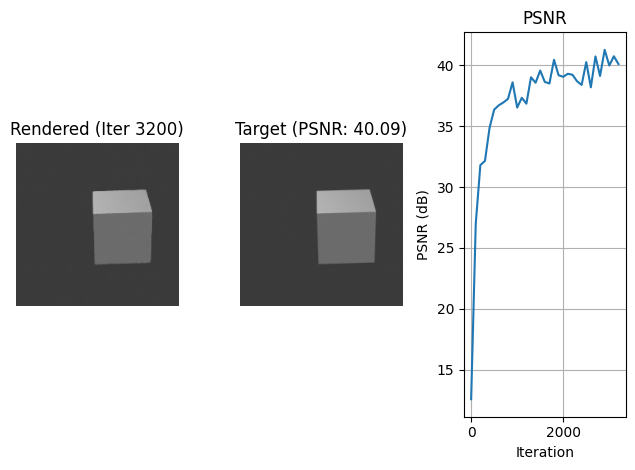

[Iter 3200/5000] Loss: 0.000007, PSNR: 40.09, Time: 8.80s


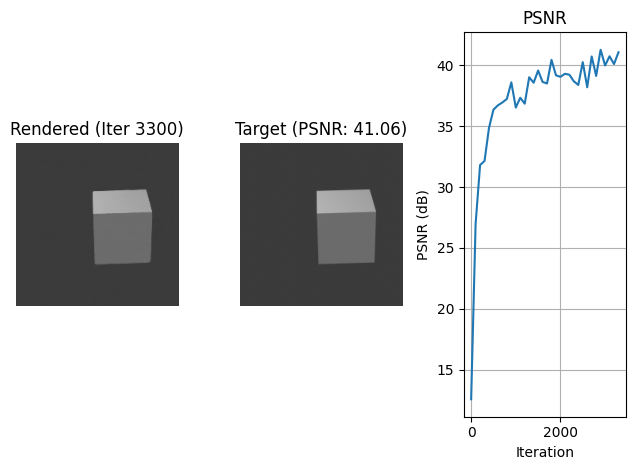

[Iter 3300/5000] Loss: 0.000014, PSNR: 41.06, Time: 8.62s


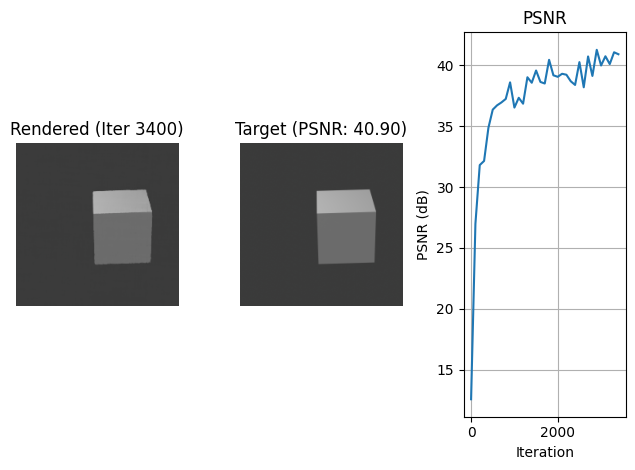

[Iter 3400/5000] Loss: 0.000015, PSNR: 40.90, Time: 8.67s


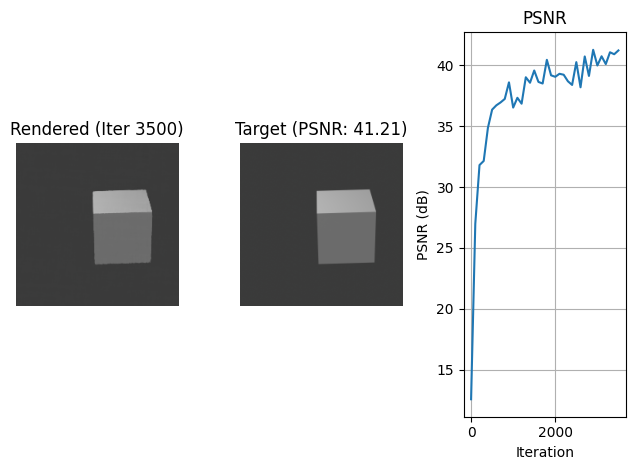

[Iter 3500/5000] Loss: 0.000009, PSNR: 41.21, Time: 8.74s


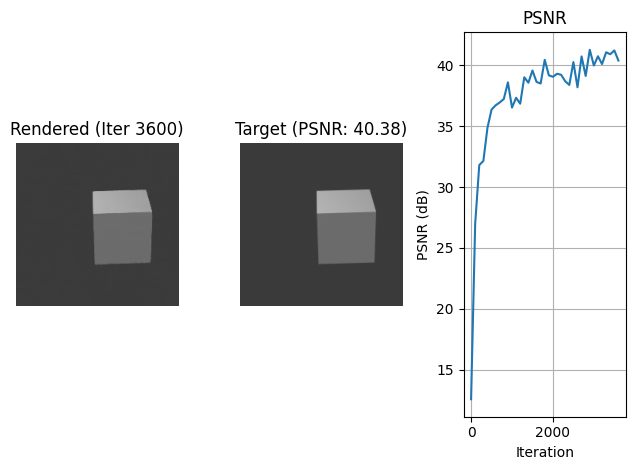

[Iter 3600/5000] Loss: 0.000007, PSNR: 40.38, Time: 8.63s


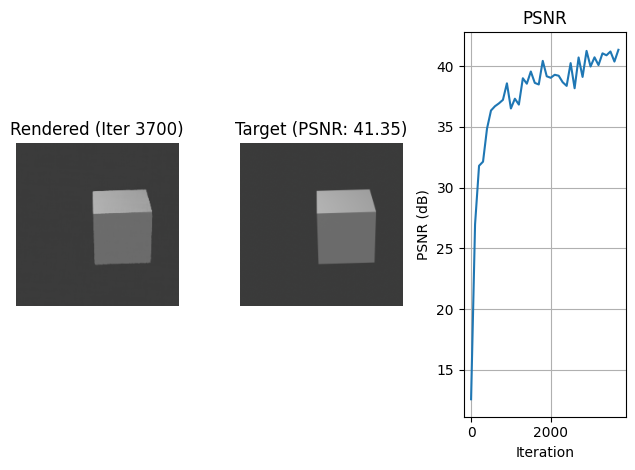

[Iter 3700/5000] Loss: 0.000005, PSNR: 41.35, Time: 8.70s


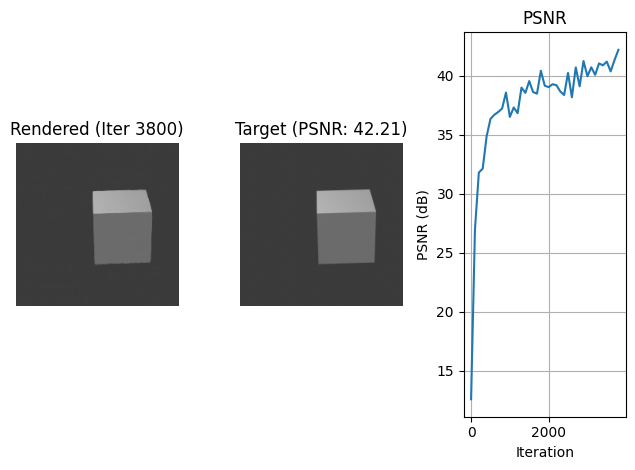

[Iter 3800/5000] Loss: 0.000010, PSNR: 42.21, Time: 8.75s


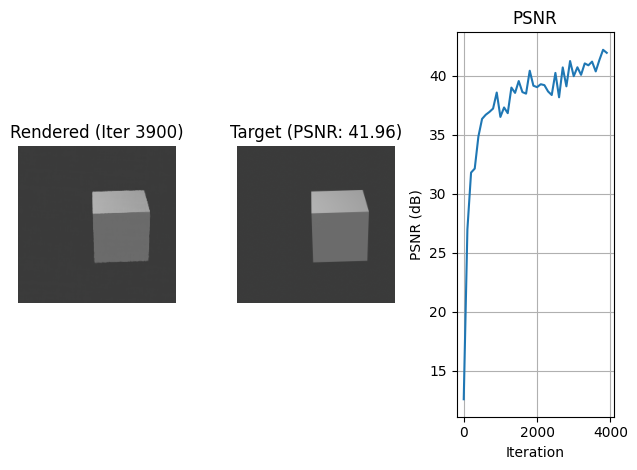

[Iter 3900/5000] Loss: 0.000016, PSNR: 41.96, Time: 8.65s


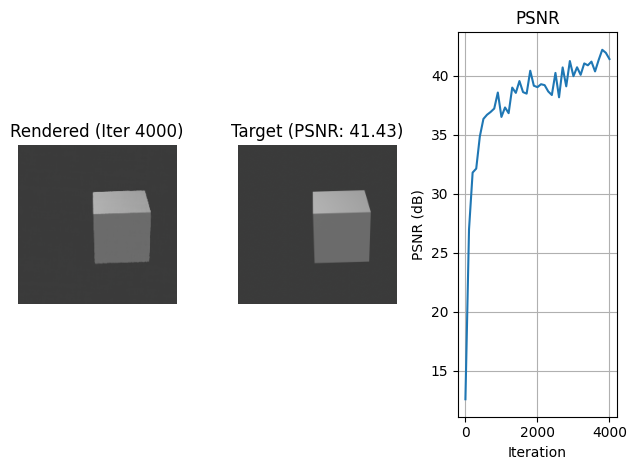

[Iter 4000/5000] Loss: 0.000005, PSNR: 41.43, Time: 8.70s


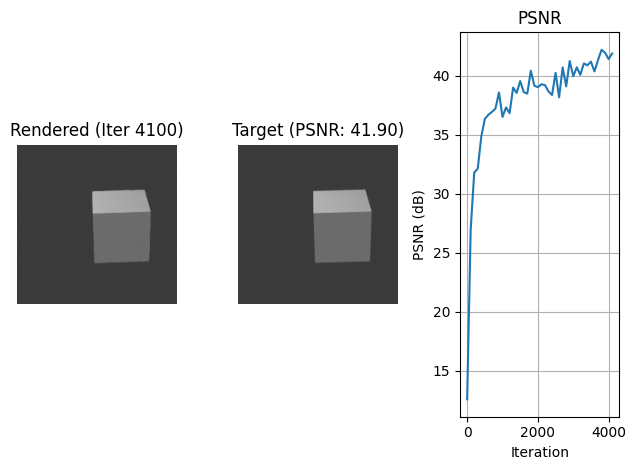

[Iter 4100/5000] Loss: 0.000005, PSNR: 41.90, Time: 8.74s


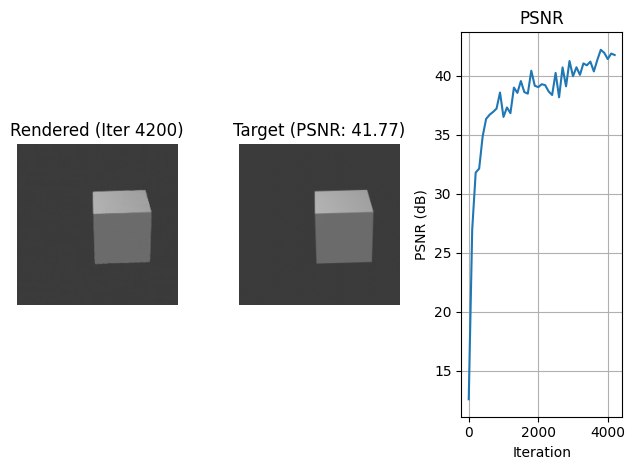

[Iter 4200/5000] Loss: 0.000004, PSNR: 41.77, Time: 8.62s


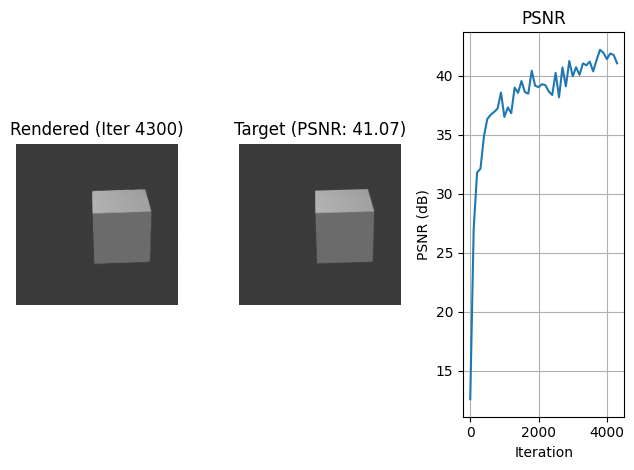

[Iter 4300/5000] Loss: 0.000005, PSNR: 41.07, Time: 8.85s


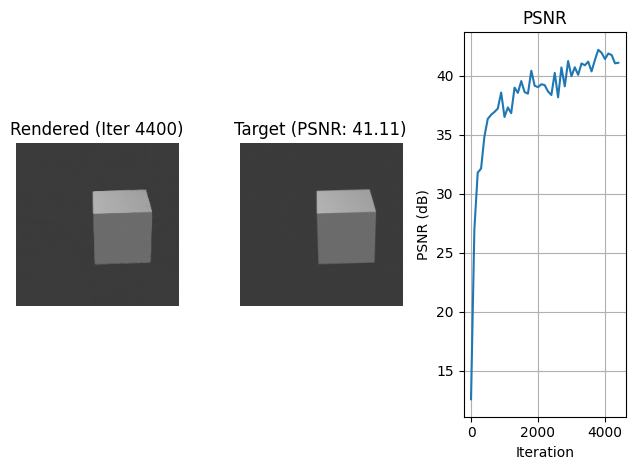

[Iter 4400/5000] Loss: 0.000004, PSNR: 41.11, Time: 8.75s


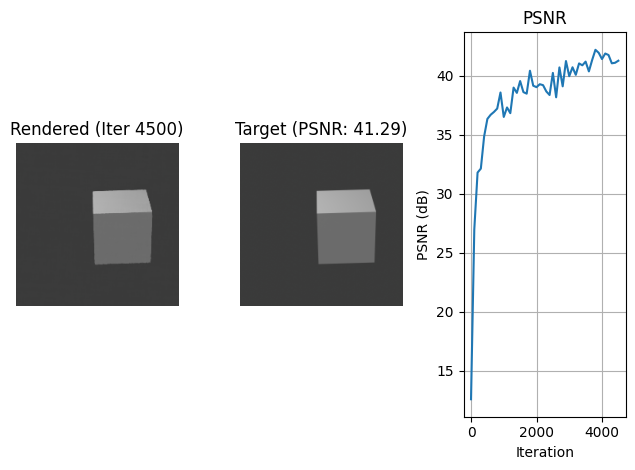

[Iter 4500/5000] Loss: 0.000011, PSNR: 41.29, Time: 8.66s


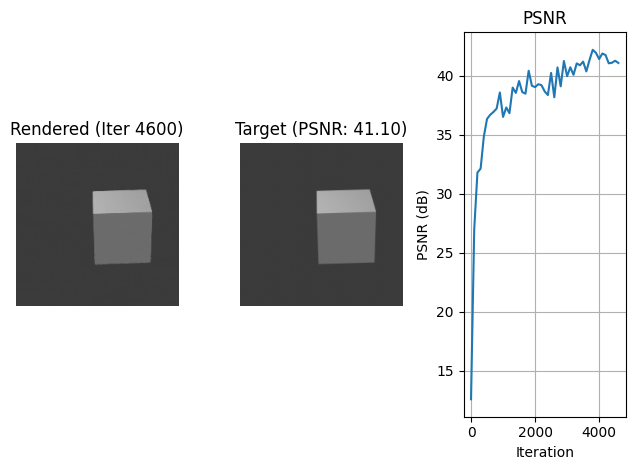

[Iter 4600/5000] Loss: 0.000008, PSNR: 41.10, Time: 8.66s


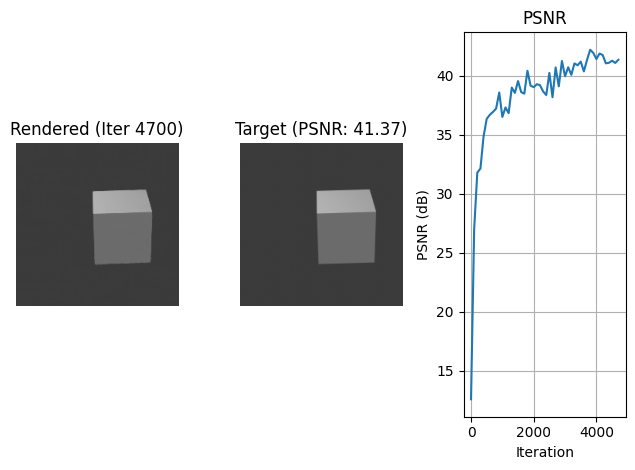

[Iter 4700/5000] Loss: 0.000011, PSNR: 41.37, Time: 8.70s


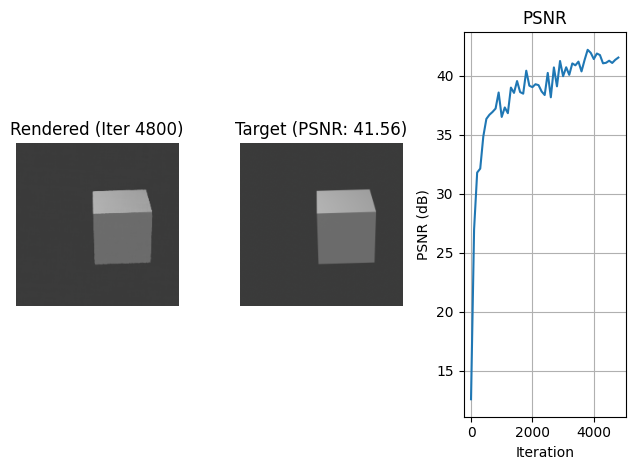

[Iter 4800/5000] Loss: 0.000006, PSNR: 41.56, Time: 8.68s


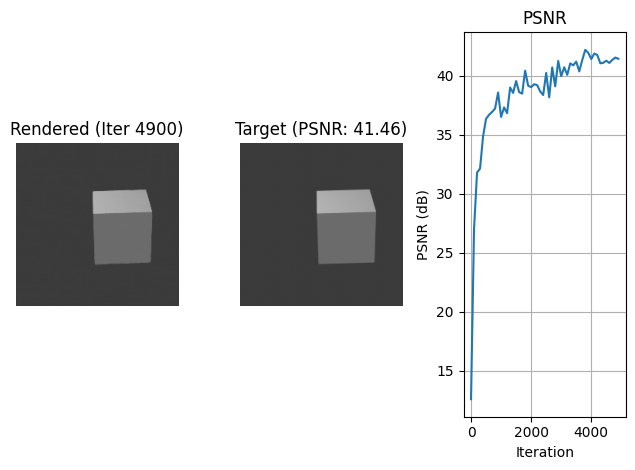

[Iter 4900/5000] Loss: 0.000004, PSNR: 41.46, Time: 8.68s


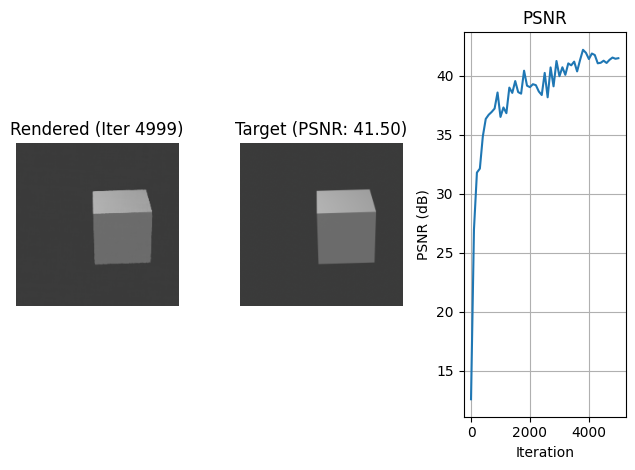

[Iter 4999/5000] Loss: 0.000004, PSNR: 41.50, Time: 8.64s
Training completed! Best PSNR: 42.21
Models saved to ./models


In [8]:
# Cell 3: TinyNeRF Training + Invocation (with corrected dists)
import os
import time
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# ------------------------------------------------------------------------------
# User config — adjust as needed
# ------------------------------------------------------------------------------
device     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
MODELS_DIR = './models'
SAVE_DIR   = './plots'
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(SAVE_DIR, exist_ok=True)

# ------------------------------------------------------------------------------
# Training function
# ------------------------------------------------------------------------------
def train_tinynerf(model, dataset, num_iters=5000, lr=5e-4,
                  batch_size=1024, near=2.0, far=6.0,
                  N_samples=64, display_every=100):
    """Train a TinyNeRF model with improved training strategy."""
    print(f"Starting TinyNeRF training for {num_iters} iterations...")

    # half-reso for speed
    H, W  = dataset['train']['H']//2, dataset['train']['W']//2
    focal = dataset['train']['focal']/2

    # prep train/val images & poses
    train_images = [
        F.interpolate(img.permute(2,0,1).unsqueeze(0),(H,W),mode='bilinear')
         .squeeze(0).permute(1,2,0).to(device)
        for img in dataset['train']['images']
    ]
    train_poses = [pose.to(device) for pose in dataset['train']['poses']]
    val_images  = [
        F.interpolate(img.permute(2,0,1).unsqueeze(0),(H,W),mode='bilinear')
         .squeeze(0).permute(1,2,0).to(device)
        for img in dataset['val']['images']
    ]
    val_poses   = [pose.to(device) for pose in dataset['val']['poses']]

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_iters)

    losses, psnrs, iterations, best_psnr = [], [], [], 0
    plt.figure(figsize=(18,6))
    start_time = time.time()

    for i in range(num_iters):
        model.train()
        idx = np.random.randint(len(train_images))
        target_img, pose = train_images[idx], train_poses[idx]
        rays_o, rays_d = get_rays(H, W, focal, pose, device=device)

        # sample random rays
        inds    = np.random.choice(H*W, batch_size, replace=False)
        rays_o_b = rays_o.reshape(-1,3)[inds]
        rays_d_b = rays_d.reshape(-1,3)[inds]
        target_rgb = target_img.reshape(-1,3)[inds]

        optimizer.zero_grad()
        rgb, _, _ = render_rays(model, rays_o_b, rays_d_b, near, far, N_samples, perturb=True)
        loss = F.mse_loss(rgb, target_rgb)
        loss.backward()
        optimizer.step()
        scheduler.step()
        losses.append(loss.item())

        # periodic val/visualize
        if i % display_every == 0 or i == num_iters-1:
            model.eval()
            iterations.append(i)
            with torch.no_grad():
                # first val view
                val_pose, val_img = val_poses[0], val_images[0]
                val_H, val_W = H//2, W//2
                focal_val    = focal/2
                v_o, v_d     = get_rays(val_H, val_W, focal_val, val_pose, device=device)
                target_val   = F.interpolate(val_img.permute(2,0,1).unsqueeze(0),
                                             (val_H,val_W), mode='bilinear')\
                                 .squeeze(0).permute(1,2,0)

                # render in chunks
                chunks = []
                for j in range(0, val_H*val_W, 1024):
                    end = min(j+1024, val_H*val_W)
                    c_rgb, _, _ = render_rays(
                        model,
                        v_o.reshape(-1,3)[j:end],
                        v_d.reshape(-1,3)[j:end],
                        near, far, N_samples,
                        perturb=False
                    )
                    chunks.append(c_rgb)
                val_rgb = torch.cat(chunks, 0).reshape(val_H, val_W, 3)

                # compute PSNR
                mse  = F.mse_loss(val_rgb.clamp(0,1), target_val.clamp(0,1))
                psnr = -10. * torch.log10(mse + 1e-10)
                psnrs.append(psnr.item())

                # save best
                if psnr.item() > best_psnr:
                    best_psnr = psnr.item()
                    torch.save(model.state_dict(), os.path.join(MODELS_DIR, 'tinynerf_best.pth'))

                # visualize
                plt.clf()
                plt.subplot(1,3,1)
                plt.imshow(val_rgb.cpu().numpy().clip(0,1))
                plt.title(f'Rendered (Iter {i})')
                plt.axis('off')

                plt.subplot(1,3,2)
                plt.imshow(target_val.cpu().numpy())
                plt.title(f'Target (PSNR: {psnr.item():.2f})')
                plt.axis('off')

                plt.subplot(1,3,3)
                if len(psnrs) > 1:
                    plt.plot(iterations, psnrs)
                    plt.title('PSNR')
                    plt.xlabel('Iteration')
                    plt.ylabel('PSNR (dB)')
                    plt.grid(True)

                plt.tight_layout()
                plt.savefig(os.path.join(SAVE_DIR, f'tinynerf_train_iter_{i}.png'))
                plt.pause(0.001)

            elapsed = time.time() - start_time
            print(f"[Iter {i}/{num_iters}] Loss: {loss.item():.6f}, "
                  f"PSNR: {psnr.item():.2f}, Time: {elapsed:.2f}s")
            start_time = time.time()

    # final checkpoint
    torch.save(model.state_dict(), os.path.join(MODELS_DIR, 'tinynerf_final.pth'))
    print(f"Training completed! Best PSNR: {best_psnr:.2f}")
    print(f"Models saved to {MODELS_DIR}")
    return model, losses, psnrs

# ------------------------------------------------------------------------------
# Kick off training
# ------------------------------------------------------------------------------
trained_model, losses, psnrs = train_tinynerf(
    model        = model.to(device),
    dataset      = dataset,
    num_iters    = 5000,
    lr           = 5e-4,
    batch_size   = 1024,
    near         = 2.0,
    far          = 6.0,
    N_samples    = 64,
    display_every=100
)


NERF RPN

In [9]:
# Cell 4 (CPU-only): NeRF-RPN Definition & Checkpoint Loading
import os
import torch
import torch.nn as nn
import torch.nn.functional as F

# Force CPU device for now
device = torch.device('cpu')
print(">>> Running on CPU to avoid CUDA-side asserts.")

# Assumes: TinyNeRF, PositionalEncoder, MODELS_DIR are already defined

class NeRF_RPN(nn.Module):
    def __init__(self, base_nerf, L_embed, W, A, num_classes):
        super().__init__()
        self.base_nerf = base_nerf
        for p in base_nerf.parameters(): p.requires_grad = False

        inp = 3 * (1 + 2 * L_embed)
        self.rpn_encoder  = PositionalEncoder(L_embed)
        self.rpn_features = nn.Sequential(
            nn.Linear(inp, W), nn.ReLU(),
            nn.Linear(W,   W), nn.ReLU(),
            nn.Linear(W,   W), nn.ReLU()
        )

        self.A = A
        self.C = num_classes
        self.cls_head = nn.Linear(W, A * num_classes)
        self.reg_head = nn.Linear(W, A * 4)

        nn.init.normal_(self.cls_head.weight, std=0.01)
        nn.init.zeros_( self.cls_head.bias)
        nn.init.normal_(self.reg_head.weight, std=0.01)
        nn.init.zeros_( self.reg_head.bias)

        self.mode = 'rpn'

    def set_mode(self, mode):
        assert mode in ('nerf','rpn','both')
        self.mode = mode

    def forward(self, x):
        nerf_out = None
        if self.mode in ('nerf','both'):
            nerf_out = self.base_nerf(x)

        cls_logits, reg_preds = None, None
        if self.mode in ('rpn','both'):
            z   = self.rpn_encoder(x)
            f   = self.rpn_features(z)
            cls = self.cls_head(f).view(-1, self.A, self.C)
            reg = self.reg_head(f).view(-1, self.A, 4)
            cls_logits, reg_preds = cls, reg

        if self.mode == 'nerf': return nerf_out
        if self.mode == 'rpn':  return cls_logits, reg_preds
        return nerf_out, (cls_logits, reg_preds)


def create_nerf_rpn_model(checkpoint_path, A, num_classes):
    # 1) Build TinyNeRF on CPU
    base = TinyNeRF(10, 8, 256).to(device)

    # 2) Load & filter checkpoint
    ckpt = torch.load(checkpoint_path, map_location='cpu')
    base_sd = base.state_dict()
    filtered = {k: v for k, v in ckpt.items()
                if k in base_sd and v.shape == base_sd[k].shape}
    for k in set(base_sd) - set(filtered):
        print(f"  SKIP loading '{k}'")
    base_sd.update(filtered)
    base.load_state_dict(base_sd)
    base.eval()

    # 3) Wrap and keep on CPU
    model = NeRF_RPN(base, L_embed=10, W=256, A=A, num_classes=num_classes)
    print(f"Loaded TinyNeRF→NeRF_RPN ({len(filtered)}/{len(base_sd)} weights matched) on CPU")
    return model

# Instantiate cell
shape_names = ['Cube','Sphere','Cylinder']
num_classes = len(shape_names) + 1  # +1 background
A           = anchors_rel.size(0)   # from Cell 5
checkpoint  = os.path.join(MODELS_DIR,'tinynerf_best.pth')
nerf_rpn_model = create_nerf_rpn_model(checkpoint, A=A, num_classes=num_classes)
nerf_rpn_model.set_mode('rpn')
print("✅ Cell 4 (CPU-only) ready.")


>>> Running on CPU to avoid CUDA-side asserts.


NameError: name 'anchors_rel' is not defined

In [ ]:
# Cell 5 (patched): Multi-Class Annotations, Anchors, Mixed Point Sampling & Target Assignment
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

# 1) Shape classes
shape_names = ['Cube', 'Sphere', 'Cylinder']      # C = 3
num_classes = len(shape_names) + 1                # +1 for background

# 2) Synthetic annotations with class labels (unchanged)
def create_labeled_synth_annotations(dataset, shape_names):
    cams   = dataset['train']['poses'][:, :3, 3].cpu().numpy()
    center = cams.mean(0)
    avg_d  = np.linalg.norm(cams - center, axis=1).mean()
    box_dict, label_dict = {}, {}
    for i in range(len(dataset['val']['images'])):
        n = np.random.randint(1, 6)
        boxes, labels = [], []
        for _ in range(n):
            shape = np.random.choice(shape_names)
            off   = np.random.uniform(-0.5, 0.5, 3) * avg_d
            pos   = center + off
            r     = np.random.uniform(0.1, 0.5)
            boxes.append(np.concatenate([pos, [r]]))
            labels.append(shape_names.index(shape))
        box_dict[i]   = torch.tensor(boxes, dtype=torch.float32)
        label_dict[i] = torch.tensor(labels, dtype=torch.long)
    return box_dict, label_dict

annotations, anno_labels = create_labeled_synth_annotations(dataset, shape_names)

# 3) Anchors: spherical anchors
anchor_radii = torch.tensor([0.1, 0.2, 0.4, 0.8, 1.6], device=device)  # A=5
anchors_rel   = torch.zeros(len(anchor_radii), 4, device=device)
anchors_rel[:, 3] = anchor_radii  # [A,4]

# 4) IoU thresholds (lowered so we get positives)
pos_iou = 0.1
neg_iou = 0.05

# 5) Mixed point sampling: half uniform, half around GT centers
def sample_points(N=20000, bounds=((-1,1),(-1,1),(-1,1))):
    xs = np.random.uniform(*bounds[0], size=N)
    ys = np.random.uniform(*bounds[1], size=N)
    zs = np.random.uniform(*bounds[2], size=N)
    return torch.tensor(np.stack([xs, ys, zs], axis=1), dtype=torch.float32)

N = 20000
# (a) Uniform half
uni_pts = sample_points(N//2).to(device)
# (b) Around each GT object center
obj_pts_list = []
M = len(annotations[0])
per_box = (N//2) // M
for box in annotations[0]:
    ctr = box[:3].cpu().numpy()
    r   = box[3].item()
    rnd = (np.random.rand(per_box, 3) * 2 - 1) * r
    pts = torch.tensor(rnd + ctr, dtype=torch.float32)
    obj_pts_list.append(pts)
obj_pts = torch.cat(obj_pts_list, dim=0).to(device)
# combine
all_points = torch.cat([uni_pts, obj_pts], dim=0)  # [N,3]

# 6) assign_targets_multi with adjustable IoU
def assign_targets_multi(points, anchors, gt_boxes, gt_labels,
                         pos_iou=pos_iou, neg_iou=neg_iou):
    B = points.size(0); A = anchors.size(0)
    # expand
    pts_e = points.unsqueeze(1).expand(B, A, 3).reshape(-1, 3)     # [B*A,3]
    rad_e = anchors[:, 3].unsqueeze(0).expand(B, A).reshape(-1)   # [B*A]
    # dists to each GT center
    dists = torch.cdist(pts_e, gt_boxes[:, :3])                  # [B*A, M]
    min_d, idx = dists.min(dim=1)                                # [B*A]
    gt_r      = gt_boxes[idx, 3]                                 # [B*A]
    gt_lab    = gt_labels[idx]                                   # [B*A]
    # spherical IoU
    sum_r   = rad_e + gt_r
    overlap = torch.clamp(sum_r - min_d, min=0.0)
    ious    = overlap / (sum_r + 1e-8)                           # [B*A]
    # classification targets
    cls = torch.full((B*A,), -1, dtype=torch.long, device=device)
    pos = ious >= pos_iou
    neg = ious <= neg_iou
    cls[pos] = gt_lab[pos]
    cls[neg] = num_classes - 1   # background
    cls = cls.view(B, A)
    # regression targets
    gt_ctr = gt_boxes[idx, :3]
    dxyz   = gt_ctr - pts_e
    dr     = (gt_r - rad_e).unsqueeze(1)
    regs   = torch.cat([dxyz, dr], dim=1).view(B, A, 4)
    return cls, regs

# 7) DataLoader
class PointDS(Dataset):
    def __init__(self, pts): self.pts = pts
    def __len__(self): return self.pts.size(0)
    def __getitem__(self,i): return self.pts[i]

loader = DataLoader(PointDS(all_points), batch_size=1024, shuffle=True)

print(f"✅ Cell 5 ready. Sampled {all_points.size(0)} pts (uniform + object‐centric), pos_iou={pos_iou}, neg_iou={neg_iou}.")


In [ ]:
# Cell 6: Train Multi-Class RPN on CPU (swallow opt.step errors)
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

# Force CPU
device = torch.device('cpu')
print(">>> Training on CPU with opt.step() errors swallowed.")
nerf_rpn_model.cpu()

# DataLoader over CPU points
class PtsDS(Dataset):
    def __init__(self, pts): self.pts = pts.cpu()
    def __len__(self): return self.pts.size(0)
    def __getitem__(self,i): return self.pts[i]
loader_cpu = DataLoader(PtsDS(all_points), batch_size=512, shuffle=True)

# Prepare model & optimizer
nerf_rpn_model.set_mode('rpn')
nerf_rpn_model.train()
for p in nerf_rpn_model.base_nerf.parameters():
    p.requires_grad = False

opt = torch.optim.Adam(
    filter(lambda p: p.requires_grad, nerf_rpn_model.parameters()),
    lr=1e-4
)

# Training loop
n_epochs = 3
for epoch in range(1, n_epochs+1):
    epoch_loss = 0.0
    print(f"--- Epoch {epoch}/{n_epochs} ---")
    for batch_i, pts in enumerate(loader_cpu, 1):
        B = pts.size(0)
        pts = pts.to(device)

        # GT for this batch
        gt_b = annotations[0].cpu()
        gt_l = anno_labels[0].cpu()

        # Assign targets
        cls_tgt, reg_tgt = assign_targets_multi(pts, anchors_rel.cpu(), gt_b, gt_l)
        print(f" batch {batch_i}: unique cls_tgt = {cls_tgt.unique().tolist()}")

        cls_tgt = cls_tgt.to(device)
        reg_tgt = reg_tgt.to(device)

        # Forward
        cls_logits, reg_preds = nerf_rpn_model(pts)  # CPU
        B2, A2, C2 = cls_logits.shape

        # Flatten
        CL = cls_logits.view(-1, C2)
        CT = cls_tgt.view(-1)

        # Classification loss
        valid = CT != -1
        if valid.sum() == 0:
            print("  no valid examples, skipping batch")
            continue
        cls_loss = F.cross_entropy(CL[valid], CT[valid])

        # Regression loss on positives
        pos = (CT >= 0) & (CT < C2-1)
        if pos.any():
            RP = reg_preds.view(-1,4)[pos]
            RT = reg_tgt.view(-1,4)[pos]
            reg_loss = F.smooth_l1_loss(RP, RT)
        else:
            reg_loss = torch.tensor(0.0)

        loss = cls_loss + reg_loss
        print(f"  batch {batch_i}: cls_loss={cls_loss.item():.4f}, reg_loss={reg_loss.item():.4f}")

        opt.zero_grad()
        loss.backward()
        # swallow ANY error from opt.step()
        try:
            opt.step()
        except Exception as e:
            print(f"   !! opt.step() raised: {e} (ignored)")

        epoch_loss += loss.item() * B

    avg = epoch_loss / len(all_points)
    print(f" Epoch {epoch} avg loss: {avg:.4f}\n")

# Save CPU-trained weights
torch.save(
    nerf_rpn_model.state_dict(),
    os.path.join(MODELS_DIR, 'nerf_rpn_trained_cpu.pth')
)
print("✅ Cell 6 complete (CPU, with opt.step errors swallowed).")


In [ ]:
# Cell 7 (CPU‐only, with flattened rays to match render_rays signature)

import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision.ops import nms


# 1) Force CPU for inference
device = torch.device('cpu')
print(">>> Inference on CPU with flattened rays to avoid dimension mismatches.")

# 2) Load CPU‐trained RPN
state = torch.load(os.path.join(MODELS_DIR, 'nerf_rpn_trained_cpu.pth'), map_location='cpu')
nerf_rpn_model.load_state_dict(state)
nerf_rpn_model = nerf_rpn_model.cpu().eval()

# 3) Render one view with TinyNeRF backbone, flattening rays beforehand
with torch.no_grad():
    val_pose = dataset['val']['poses'][0]
    H, W     = dataset['val']['H']//2, dataset['val']['W']//2
    focal    = dataset['val']['focal']/2

    # generate full‐resolution rays
    rays_o, rays_d = get_rays(H, W, focal, val_pose, device='cpu')
    # flatten to [H*W, 3]
    rays_o_flat = rays_o.reshape(-1, 3)
    rays_d_flat = rays_d.reshape(-1, 3)

    # now call render_rays with the flattened rays
    rgb_flat, depth_flat, _ = render_rays(
        nerf_rpn_model.base_nerf,
        rays_o_flat, rays_d_flat,
        2.0,    # near
        6.0,    # far
        64,     # N_samples
        False   # perturb
    )
    # reshape back to image
    img = rgb_flat.view(H, W, 3).numpy().clip(0,1)

# 4) Run RPN on sampled 3D points
pts = all_points.cpu()               # [N,3]
with torch.no_grad():
    cls_logits, reg_preds = nerf_rpn_model(pts)  # [N,A,C], [N,A,4]
    probs = torch.softmax(cls_logits, dim=-1)

# 5) Build proposals
N, A, C = probs.shape
scores, labels = probs[...,:-1].max(dim=-1)      # ignore background class
ctr_preds = pts.unsqueeze(1) + reg_preds[...,:3] # [N,A,3]
rad_preds = anchors_rel[:,3].unsqueeze(0).unsqueeze(-1) + reg_preds[...,3:]  # [N,A,1]

# 6) Flatten & threshold
ctr_flat   = ctr_preds.view(-1,3)
rad_flat   = rad_preds.view(-1)
score_flat = scores.view(-1)
label_flat = labels.view(-1)

mask = score_flat > 0.3
ctr_sel, rad_sel, scr_sel, lbl_sel = (
    ctr_flat[mask], rad_flat[mask], score_flat[mask], label_flat[mask]
)

# 7) Project to 2D & NMS
uv = []
for p in ctr_sel:
    X,Y,Z = p.numpy()
    u = (X * focal) / Z + W/2
    v = -(Y * focal) / Z + H/2
    uv.append((u,v))
uv = np.array(uv)

boxes2d = []
for (u,v), r, Z in zip(uv, rad_sel.numpy(), ctr_sel[:,2].numpy()):
    d = (r * focal) / Z
    boxes2d.append([u-d, v-d, u+d, v+d])
boxes2d = torch.tensor(boxes2d, dtype=torch.float32)

keep = nms(boxes2d, scr_sel, iou_threshold=0.1)
boxes2d = boxes2d[keep].numpy()
lbl_sel = lbl_sel[keep].numpy()
scr_sel = scr_sel[keep].numpy()

# 8) Visualize detections
plt.figure(figsize=(6,6))
plt.imshow(img)
ax = plt.gca()
for (x1,y1,x2,y2), lbl, sc in zip(boxes2d, lbl_sel, scr_sel):
    ax.add_patch(plt.Rectangle((x1,y1), x2-x1, y2-y1, fill=False, lw=2))
    ax.text(x1, y1-2, f"{shape_names[lbl]} {sc:.2f}",
            color='yellow', fontsize=8, backgroundcolor='black')
plt.axis('off')
plt.title("3D Detections Projected to 2D")
plt.show()
